In [1]:
from glob import glob
from omegaconf import OmegaConf
import pandas as pd
import matplotlib.pyplot as plt

def load(path):
    r = OmegaConf.load(path)
    name = path.split('/')[-2]
    r['name'] = name
    return r

def plot_train(run_summary):
    epochs = run_summary.curve.epoch
    train = run_summary.curve.train_loss
    val = run_summary.curve.val_loss
    best_epoch = run_summary.best_epoch
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, train, label="train")
    ax.plot(epochs, val, label="val")
    ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return ax
    
def plot_lr(run_summary):
    epochs = run_summary.curve.epoch
    lr = run_summary.curve.lr
    best_epoch = run_summary.best_epoch
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, lr, label="lr")
    ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return ax

In [2]:
!pushd ..; ./rsync.sh ; popd
path_list = glob("../out/kfp/*/run_summary.yaml")
print(len(path_list))
d = {path.split('/')[-2]: OmegaConf.load(path) for path in path_list} 

At file://out/kfp/**, worker process 10560 thread 8274942144 listed 594...
At gs://demand-vision/temp/marc/runs/**, worker process 10560 thread 8274942144 listed 614...
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo3/best_model.pt to file://out/kfp/lstm_ema_mimo3/best_model.pt
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo3/curves.png to file://out/kfp/lstm_ema_mimo3/curves.png
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo3/run_summary.yaml to file://out/kfp/lstm_ema_mimo3/run_summary.yaml
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo3/src.tar.gz to file://out/kfp/lstm_ema_mimo3/src.tar.gz
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo3/train.log to file://out/kfp/lstm_ema_mimo3/train.log
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo4/best_model.pt to file://out/kfp/lstm_ema_mimo4/best_model.pt
Copying gs://demand-vision/temp/marc/runs/lstm_ema_mimo4/curves.png to file://out/kfp/lstm_ema_mimo4/curves.png
Copying gs://demand-visio

In [3]:
df = pd.DataFrame([load(path) for path in path_list])
df = df['name best_val_loss best_epoch max_epochs'.split()]
df = df.set_index('name')
df = df.sort_values('best_val_loss')
df['iob%'] = 100 * (1 - df['best_val_loss'] / df.loc['baseline', 'best_val_loss'])
df.head(25)

,best_val_loss,best_epoch,max_epochs,iob%
name,,,,
lstm_ema_embnorm,0.089337,4,50,1.979547
lstm_ema_warm1,0.089484,3,50,1.818422
lstm_ema_warmup,0.089485,5,50,1.817141
lstm_ema_mimo3,0.089565,10,50,1.729318
lstm_ema_mimo4,0.089650,26,50,1.635831
lstm_ema_quantile,0.089667,4,50,1.617530
lstm_ema_mimo_rep07,0.089678,6,50,1.604927
lstm_ema_nosoftplus,0.089713,6,50,1.566618
lstm_ema_scale,0.089729,3,50,1.549110


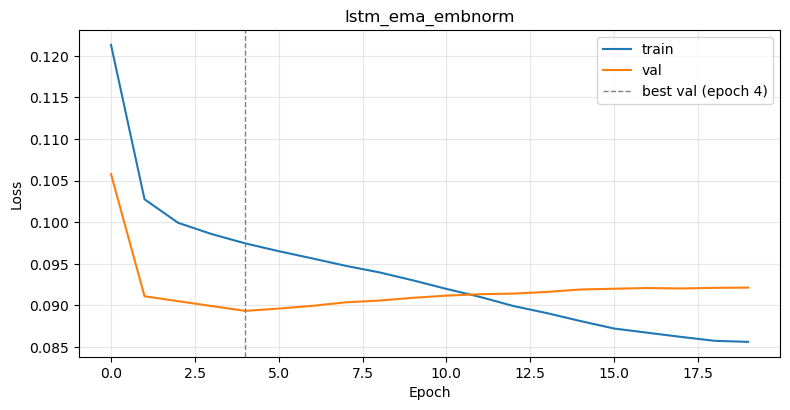

In [4]:
name = df.index[0]
# name = 'tcn_ema'
ax = plot_train(d[name])
ax.set_title(name);

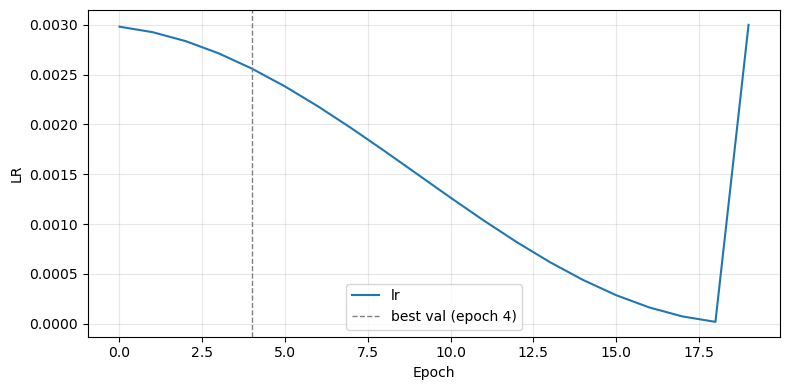

In [5]:
plot_lr(d[name]);

In [6]:
# df['best_val_loss'].sort_values(ascending=False).plot(kind='barh', figsize=(8, 12))

In [7]:
# import numpy as np
# np.log(df['best_val_loss']).hist(bins=100)

In [8]:
# for name in ['baseline', 'lstm_ema_lr003']:
#     ax = plot_curves(d[name])
#     ax.set_title(name);

In [9]:
d['baseline']

{'best_val_loss': 0.09114120578643208, 'best_epoch': 9, 'max_epochs': 50, 'curve': {'epoch': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], 'train_loss': [0.13745302730132328, 0.105763014101374, 0.10231217858638154, 0.10065598249265913, 0.09899213037778379, 0.09798813516448242, 0.09715265650110147, 0.09608005858504853, 0.09533113794228465, 0.09446567695070067, 0.0935929429581951, 0.09297189081648555, 0.09219727216773808, 0.0914924007413695, 0.09098330982243977, 0.0901606182358865, 0.08968302639717103, 0.08894255890425228, 0.08855235840697497, 0.08795235138499055, 0.08757367873828563, 0.08719363735265, 0.0867352855907951, 0.08634935979725752, 0.08589823733931795], 'val_loss': [0.10410955878508436, 0.09776929222762858, 0.09601355873462858, 0.09426435971740497, 0.09425556597515668, 0.09264112959286516, 0.09350872651401271, 0.09227468903182165, 0.091354930813129, 0.09114120578643208, 0.09123426012939023, 0.09218086537382589, 0.09233642962942945,